In [2]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow import keras

In [3]:
df = pd.read_csv("GOOGL.csv")
print(df.head())

         Date       Open       High        Low      Close  Adj Close    Volume
0  2004-08-19  50.050049  52.082081  48.028027  50.220219  50.220219  44659096
1  2004-08-20  50.555557  54.594597  50.300301  54.209209  54.209209  22834343
2  2004-08-23  55.430431  56.796799  54.579578  54.754753  54.754753  18256126
3  2004-08-24  55.675674  55.855858  51.836838  52.487488  52.487488  15247337
4  2004-08-25  52.532532  54.054054  51.991993  53.053055  53.053055   9188602


In [4]:
data = df['Close'].values
data = data.reshape(-1, 1)

In [5]:
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data)

In [6]:
X = []
y = []

time_step = 60

for i in range(time_step, len(data_scaled)):
    X.append(data_scaled[i-time_step:i, 0])
    y.append(data_scaled[i, 0])

X = np.array(X)
y = np.array(y)

In [7]:
X = X.reshape(X.shape[0], X.shape[1], 1)

In [8]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [9]:
model = keras.Sequential([
    keras.layers.LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    keras.layers.LSTM(50),
    keras.layers.Dense(1)
])

c:\Users\Aditya.konde\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [11]:
model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32
)

Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 8.9179e-04
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 4.6569e-05
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 4.8179e-05
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 4.4434e-05
Epoch 5/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 4.2252e-05
Epoch 6/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 3.8302e-05
Epoch 7/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 3.7182e-05
Epoch 8/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 4.0190e-05
Epoch 9/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 3.4315e-05
Epoch 10/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 3.5321e-05


In [12]:
predicted = model.predict(X_test)

# Convert back to original scale
predicted = scaler.inverse_transform(predicted.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


In [13]:
for i in range(5):
    print("Actual:", y_test_actual[i][0], "Predicted:", predicted[i][0])

Actual: 1211.530029 Predicted: 1200.2422
Actual: 1177.069946 Predicted: 1203.7013
Actual: 1167.829956 Predicted: 1204.8826
Actual: 1155.920044 Predicted: 1204.0555
Actual: 1145.170044 Predicted: 1201.2426


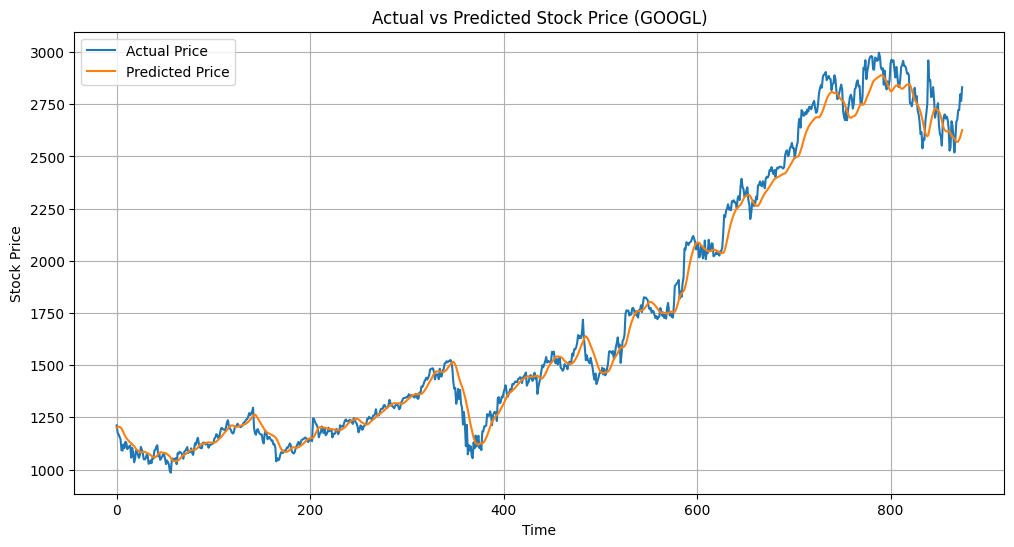

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label='Actual Price')
plt.plot(predicted, label='Predicted Price')

plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("Actual vs Predicted Stock Price (GOOGL)")
plt.legend()
plt.grid(True)

plt.show()